In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

<Axes: >

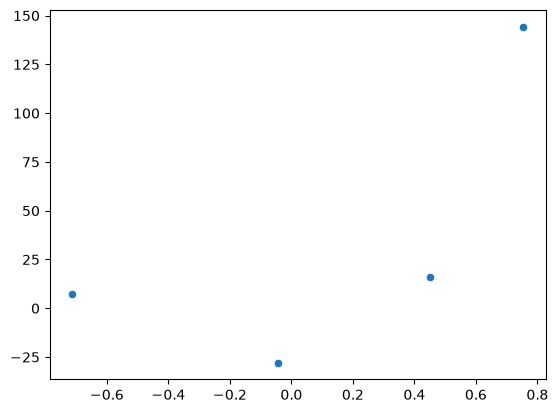

In [2]:
sns.scatterplot(x=X.ravel(), y=y)

In [3]:
X.shape, y.shape

((4, 1), (4,))

In [4]:
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [5]:
lr.coef_

array([78.35063668])

In [6]:
lr.intercept_

np.float64(26.15963284313262)

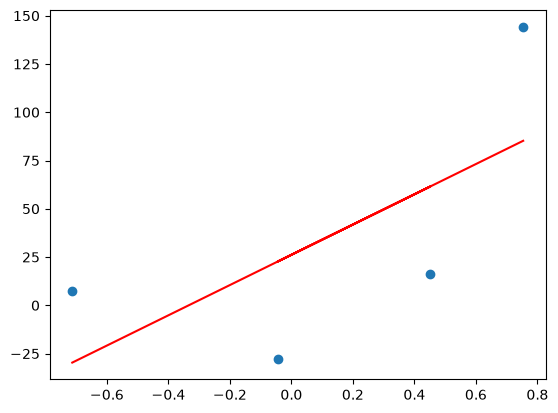

In [7]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='red')

# Lets start

In [8]:
#Iteration 1

In [9]:
# Will takeing the m as a constant and perform grdient discent step by step
# m = 78.35

In [27]:
m = 78.35
# Lets take random number for b (anynumber)
b = 0
learning_rate = 0.1

In [11]:
y_pred = (m*X+b).ravel()

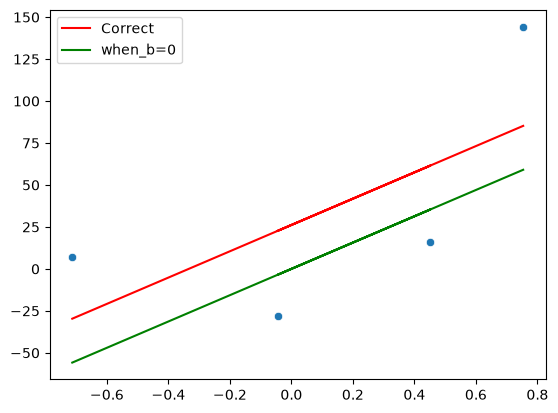

In [12]:
sns.scatterplot(x=X.ravel(), y=y)
plt.plot(X, lr.predict(X), color='red', label='Correct')
plt.plot(X, y_pred, color='green', label='when_b=0')
plt.legend()

In [13]:
#Iteration 2

In [26]:
slope = -2 * np.sum(y - m * X.ravel() - b)
slope

np.float64(-209.27763408209216)

In [28]:
# b will update now
b1 = b - learning_rate * slope
b1

np.float64(20.927763408209216)

In [29]:
y_pred1 = (m*X+b1).ravel()

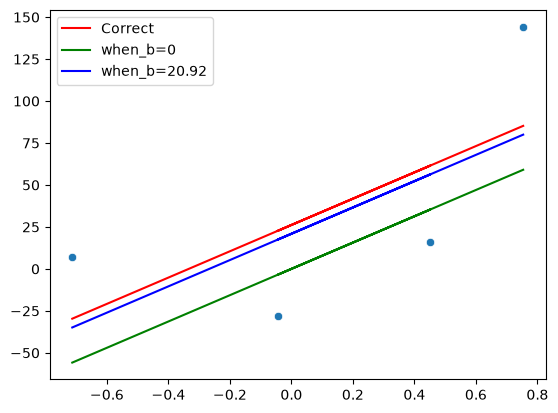

In [52]:
sns.scatterplot(x=X.ravel(), y=y)
plt.plot(X, lr.predict(X), color='red', label='Correct')
plt.plot(X, y_pred, color='green', label='when_b=0')
plt.plot(X, y_pred1, color='blue', label='when_b=20.92')
plt.legend()

In [31]:
#Iteration 3

In [42]:
slope = -2 * np.sum(y - m * X.ravel() - b1)
slope

np.float64(-41.85552681641845)

In [43]:
b2 = b1 - learning_rate * slope
b2

np.float64(25.11331608985106)

In [44]:
y_pred2 = (m*X+b2).ravel()

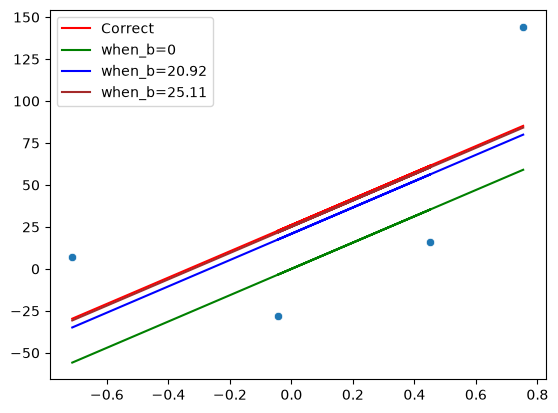

In [53]:
sns.scatterplot(x=X.ravel(), y=y)
plt.plot(X, lr.predict(X), color='red', label='Correct')
plt.plot(X, y_pred, color='green', label='when_b=0')
plt.plot(X, y_pred1, color='blue', label='when_b=20.92')
plt.plot(X, y_pred2, color='brown', label='when_b=25.11')
plt.legend()

In [36]:
#Iteration 4

In [47]:
slope = -2 * np.sum(y - m * X.ravel() - b2)
slope

np.float64(-8.37110536328369)

In [48]:
b3 = b2 - learning_rate * slope
b3

np.float64(25.95042662617943)

In [59]:
y_pred3 = (m*X+b3).ravel()

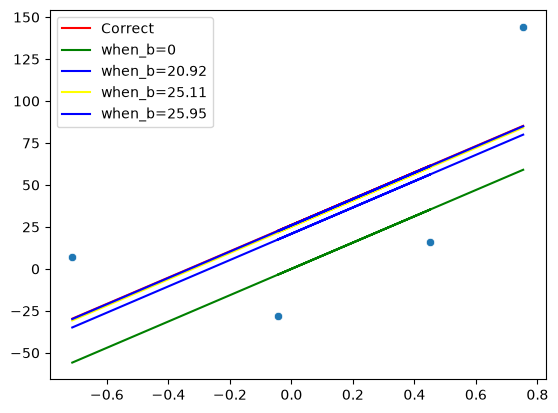

In [60]:
sns.scatterplot(x=X.ravel(), y=y)
plt.plot(X, lr.predict(X), color='red', label='Correct')
plt.plot(X, y_pred, color='green', label='when_b=0')
plt.plot(X, y_pred1, color='blue', label='when_b=20.92')
plt.plot(X, y_pred2, color='yellow', label='when_b=25.11')
plt.plot(X, y_pred3, color='blue', label='when_b=25.95')
plt.legend()

In [73]:
# Lets do in loop
# and play

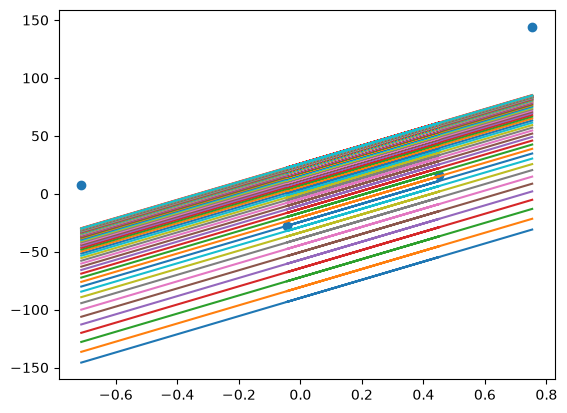

In [86]:
b = -100
m = 78.35
learning_rate = 0.01
epochs = 70
y_pred = m * X.ravel() + b
plt.plot(X, lr.predict(X), color='red')
for _ in range(epochs):
    b = b - learning_rate * (-2 * np.sum(y - m * X.ravel() - b))
    y_pred = m * X.ravel() + b
    plt.plot(X, y_pred)
plt.scatter(X, y)